In [3]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('../data/processed/model_train.csv')
val_df = pd.read_csv('../data/processed/model_val.csv')
test_df = pd.read_csv('../data/processed/model_test.csv')

In [4]:
EXCLUDE_FROM_AUTOENCODER = ['Time', 'Hour', 'Day', 'Time_of_day', 'Amount']
# Excluded because:
# - Time/Hour/Day/Time_of_day: the chronological split means these have a


candidate_df = train_df.drop(columns=['Class'] + EXCLUDE_FROM_AUTOENCODER)
numeric_features = candidate_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = candidate_df.select_dtypes(include=['object']).columns.tolist()
print(f"{len(numeric_features)} numeric, {len(categorical_features)} categorical: {categorical_features}")

31 numeric, 0 categorical: []


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([('scaler', StandardScaler())])
categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [6]:
X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']
X_val = val_df.drop(columns=['Class'])
y_val = val_df['Class']
X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(X_train_proc.shape, X_val_proc.shape, X_test_proc.shape)

(198608, 31) (42559, 31) (42559, 31)


In [7]:
# validation-for-early-stopping — this is what makes it unsupervised.
X_train_normal = X_train_proc[y_train.values == 0]
X_val_normal = X_val_proc[y_val.values == 0]

print(f"Training on {X_train_normal.shape[0]:,} normal transactions "
      f"(excluded {y_train.sum()} fraud rows from training)")

Training on 198,242 normal transactions (excluded 366 fraud rows from training)


In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
input_dim = X_train_proc.shape[1]

encoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),  # bottleneck
], name="encoder")

decoder = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(input_dim, activation='linear'),
], name="decoder")

autoencoder = keras.Sequential([encoder, decoder], name="autoencoder")
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 8)              │         1,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 31)             │         1,711 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,399 (13.28 KB)

 Trainable params: 3,399 (13.28 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
## Training — early stopping + learning-rate scheduling

## Required per the Deep Learning Track spec (item 41 in the parent doc, and generally across every project's DL track). `EarlyStopping` restores the best-val-loss weights; `ReduceLROnPlateau` handles the learning-rate scheduling.

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

history = autoencoder.fit(
    X_train_normal, X_train_normal,
    validation_data=(X_val_normal, X_val_normal),
    epochs=100,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

Epoch 1/100
775/775 - 3s - 4ms/step - loss: 0.7446 - val_loss: 0.7403 - learning_rate: 0.0010
Epoch 2/100
775/775 - 1s - 2ms/step - loss: 0.5698 - val_loss: 0.6090 - learning_rate: 0.0010
Epoch 3/100
775/775 - 1s - 1ms/step - loss: 0.5029 - val_loss: 0.5380 - learning_rate: 0.0010
Epoch 4/100
775/775 - 1s - 1ms/step - loss: 0.4723 - val_loss: 0.5106 - learning_rate: 0.0010
Epoch 5/100
775/775 - 1s - 1ms/step - loss: 0.4578 - val_loss: 0.4895 - learning_rate: 0.0010
Epoch 6/100
775/775 - 1s - 1ms/step - loss: 0.4458 - val_loss: 0.4748 - learning_rate: 0.0010
Epoch 7/100
775/775 - 1s - 1ms/step - loss: 0.4351 - val_loss: 0.4643 - learning_rate: 0.0010
Epoch 8/100
775/775 - 1s - 1ms/step - loss: 0.4275 - val_loss: 0.4608 - learning_rate: 0.0010
Epoch 9/100
775/775 - 1s - 1ms/step - loss: 0.4216 - val_loss: 0.4576 - learning_rate: 0.0010
Epoch 10/100
775/775 - 1s - 1ms/step - loss: 0.4160 - val_loss: 0.4563 - learning_rate: 0.0010
Epoch 11/100
775/775 - 1s - 1ms/step - loss: 0.4094 - val_l

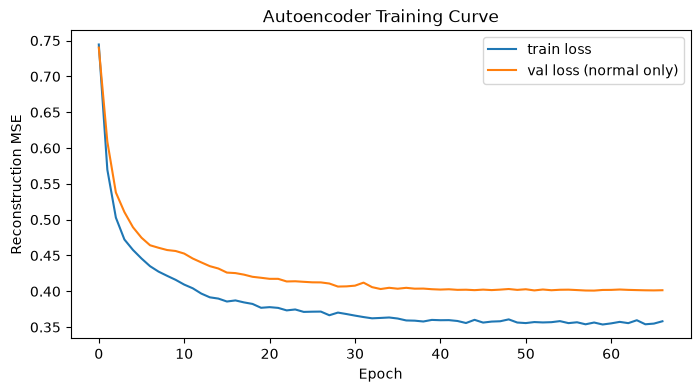

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss (normal only)')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction MSE')
plt.title('Autoencoder Training Curve')
plt.legend()
plt.show()

In [12]:
## Reconstruction error as the anomaly score
#Note this is computed on **all** rows (normal + fraud) in val/test — the model just never got to train on the fraud ones.**

In [13]:
def reconstruction_error(model, X):
    recon = model.predict(X, verbose=0)
    return np.mean(np.square(X - recon), axis=1)

val_errors = reconstruction_error(autoencoder, X_val_proc)
test_errors = reconstruction_error(autoencoder, X_test_proc)

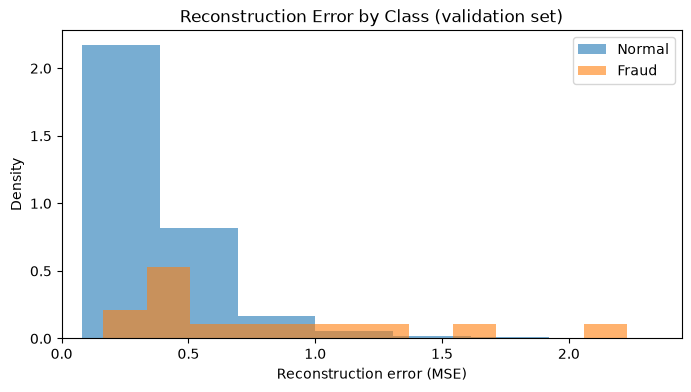

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(val_errors[y_val.values == 0], bins=80, alpha=0.6, label='Normal', density=True)
plt.hist(val_errors[y_val.values == 1], bins=80, alpha=0.6, label='Fraud', density=True)
plt.xlabel('Reconstruction error (MSE)')
plt.ylabel('Density')
plt.title('Reconstruction Error by Class (validation set)')
plt.legend()
plt.xlim(0, np.percentile(val_errors, 99.5))
plt.show()

In [15]:
## Threshold tuning

##Same principle as the ML track: don't pick a threshold blind, and don't tune it on the test set. Sweep the precision-recall curve **on validation** and pick the point that maximizes F1 — then apply that fixed threshold once to test.

In [16]:
from sklearn.metrics import (
    precision_recall_curve, f1_score, classification_report,
    confusion_matrix, roc_auc_score, average_precision_score
)

precisions, recalls, thresholds = precision_recall_curve(y_val, val_errors)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1s[:-1])  # last point has no matching threshold
best_threshold = thresholds[best_idx]

print(f"Chosen threshold (max F1 on val): {best_threshold:.5f}")
print(f"Val precision={precisions[best_idx]:.3f}  "
      f"recall={recalls[best_idx]:.3f}  F1={f1s[best_idx]:.3f}")

Chosen threshold (max F1 on val): 7.58608
Val precision=0.440  recall=0.400  F1=0.419


In [17]:
## Test set evaluation

In [18]:
test_pred = (test_errors > best_threshold).astype(int)

print(classification_report(y_test, test_pred, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, test_errors):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, test_errors):.4f}")

              precision    recall  f1-score   support

           0      0.999     1.000     1.000     42507
           1      0.677     0.404     0.506        52

    accuracy                          0.999     42559
   macro avg      0.838     0.702     0.753     42559
weighted avg      0.999     0.999     0.999     42559

Confusion matrix:
[[42497    10]
 [   31    21]]
ROC-AUC: 0.9176
PR-AUC:  0.3801


In [19]:
ae_recall = None
from sklearn.metrics import recall_score, precision_score
ae_recall = recall_score(y_test, test_pred)
ae_precision = precision_score(y_test, test_pred)
ae_f1 = f1_score(y_test, test_pred)
ae_roc_auc = roc_auc_score(y_test, test_errors)
ae_pr_auc = average_precision_score(y_test, test_errors)
print(f"AE Recall: {ae_recall:.4f}")
print(f"AE Precision: {ae_precision:.4f}")
print(f"AE F1: {ae_f1:.4f}")
print(f"ROC-AUC:{ae_roc_auc:.4f}")
print(f"PR-AUC:{ae_pr_auc:.4f}")

AE Recall: 0.4038
AE Precision: 0.6774
AE F1: 0.5060
ROC-AUC:0.9176
PR-AUC:0.3801


In [21]:
import joblib
import os

os.makedirs("../models/anomaly", exist_ok=True)
autoencoder.save("../models/anomaly/autoencoder.keras")
joblib.dump(preprocessor, "../models/anomaly/autoencoder_preprocessor.joblib")
joblib.dump({'threshold': best_threshold}, "../models/anomaly/autoencoder_threshold.joblib")

print("Saved: ../models/anomaly/autoencoder.keras")
print("Saved: ../models/anomaly/autoencoder_preprocessor.joblib")
print(f"Saved threshold ({best_threshold:.5f}): ../models/anomaly/autoencoder_threshold.joblib")

Saved: ../models/anomaly/autoencoder.keras
Saved: ../models/anomaly/autoencoder_preprocessor.joblib
Saved threshold (7.58608): ../models/anomaly/autoencoder_threshold.joblib
